In [1]:
from pathlib import Path

from jax import config
import jax.numpy as np
config.update("jax_enable_x64", True)

from gwfast.lensing_utils import compute_exact_lensed_angles


Text(0.5, 0, '$R_{\\rm orb}\\,/\\,R_{\\rm Sch}$')

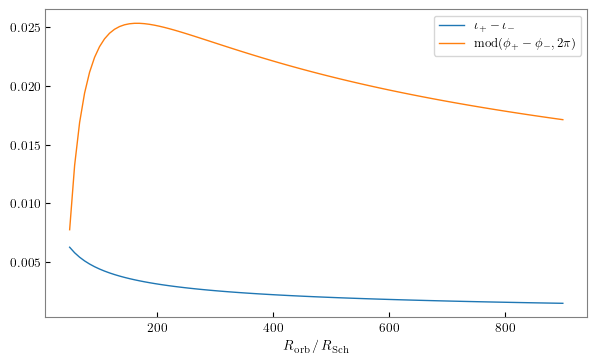

In [21]:
size = 100
r_orbits = np.linspace(50, 900, size)
lensing_params = {
    'iota': np.full(size, np.pi/2 * 0.99),
    'Phicoal': np.full(size, 1.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}

lensed_params = compute_exact_lensed_angles(lensing_params)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], label=r'$\iota_+ - \iota_-$')
ax.plot(r_orbits, np.mod(lensed_params['phase_p'] - lensed_params['phase_m'], 2*np.pi), label=r'${\rm mod}(\phi_+ - \phi_-, 2\pi)$')
ax.legend()
ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')